# Vibe Coding a modern diffusion pipeline (NVIDIA EDM, SR3, Toyota SR)

* Nvidia - Elucidating the Design Space of Diffusion-Based Generative Models - https://arxiv.org/abs/2206.00364
* Toyota - Efficient Burst Super-Resolution with One-step Diffusion - https://arxiv.org/abs/2507.13607
* Google SR3 - Image Super-Resolution via Iterative Refinement - https://arxiv.org/abs/2104.07636


## 1. Install and Import Required Libraries

We will use PyTorch, torchvision, numpy, matplotlib, and tqdm. If running locally, ensure these packages are installed.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import base64
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import random
import time
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision import transforms
from datetime import datetime
from io import BytesIO
from PIL import Image, ImageOps
from tqdm import tqdm
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import io
import os

In [2]:
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_diffusion
from elucidated_diffusion.elucidated_diffusion import edm_ancestral_sampling_for_sr
from elucidated_diffusion.elucidated_diffusion import P_mean, P_std, sigma_data, edm_loss_weight
from elucidated_diffusion.ema_helper import EMAHelper
from elucidated_diffusion.models.chatgpt_diffusion_unet import UNet128
from elucidated_diffusion.models.claude_diffusion_ViTEnhancedUNet64 import create_vit_enhanced_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_diffusion_ViTGradualTransition import create_gradual_transition_unet
from elucidated_diffusion.models.claude_SemanticCoordinatorViTUNet import create_semantic_coordinator
from elucidated_diffusion.dataset_helpers import get_datasets
from elucidated_diffusion.checkpoint_helper import load_checkpoint, save_checkpoint

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HR = 256
LR = 64
# max_training_time = 60*5
# display_interval = 30

# # https://www.kaggle.com/datasets/chetankv/dogs-cats-images
# # https://www.kaggle.com/datasets/nerfviking/fantasyscifi-full-body-character-concepts
# # https://www.kaggle.com/datasets/hlrhegemony/pokemon-image-dataset
# experiments = {
#     "fantasy": ("./data/fantasy", "checkpoints/UNet128_2025-09-14_17-47-44_fantasy.pth", "checkpoints/UNetSR3_2025-09-14_17-32-01_fantasy.pth"),
#     "cats_and_dogs": ("./data/cats_and_dogs/dataset/training_set", "checkpoints/UNet128_2025-09-08_17-57-30_cats_and_dogs.pth",None),
#     "pokemon": ("./data/pokemon_archive","UNet128_2025-09-12_11-03-12_pokemon.pth",None),
#     "dragon": ("utils/dataset_fetcher/datasets/", 'checkpoints/UNet128_2025-09-17_01-57-51_dragon.pth',None),
#     "yugioh": ("data/yugioh/YuGiOhImages",None,None),
#     "mnist": (None,None,None),
# }

# src_data, diffusion_weights,checkpoint_weights = experiments[experiment_name]


## 3. Define a Vision Model for a Diffusion Model Architecture

* **Sinusoidal Timestep Embedding**
  * → Encodes diffusion step (time) as a multi-frequency vector. Lets the model “know” how much noise is present and what stage of denoising it’s in.
* **Optional Self-Attention at Lower Resolutions (e.g. 16×16)**
  * → Lets distant parts of the image “talk to each other,” useful for global structure (symmetry, object coherence). Limited to low-res maps to save compute.
* **SiLU/Swish activations**
  * → Smooth nonlinearities, empirically better than ReLU in diffusion U-Nets.

AdaptiveSemanticCoordinatorUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
  )
  (input_block): ConvBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=128, out_features=64, bias=True)
    (skip): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (input_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (encoder_blocks): ModuleList(
    (0): ConvBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_mlp): Linear(in_features=128, out_features=64, bias=True)
      (skip): Identity()
    )
    (1): ConvBlock(
      (conv1): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(256, 256, ke

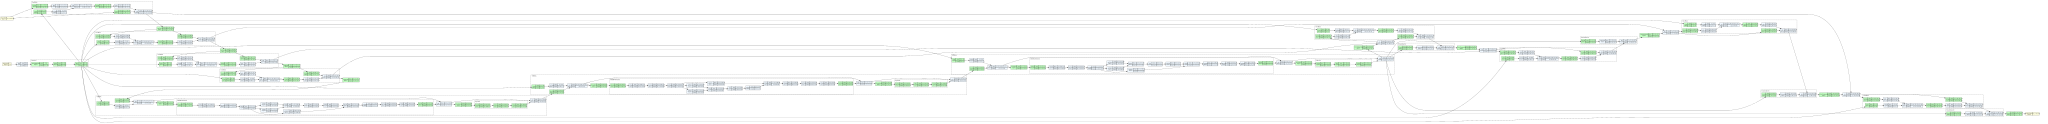

In [4]:
def show_model_info():
    img_size=128
    #model = UNet128(use_attention=True).to(device)
    #model = create_gradual_transition_unet().to(device)
    #model = create_vit_enhanced_unet().to(device)
    model = create_semantic_coordinator(img_size=img_size,config='balanced').to(device)
    print(model)

    # Total parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params}")

    # Trainable parameters
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params}")

    from torchview import draw_graph
    #model = UNet128(use_attention=True).to(device)
    x,t = torch.rand(12, 3, img_size, img_size), torch.rand(12)

  
    #print(x,t)
    model_graph = draw_graph(model, input_data=(x,t), device='meta',
                            expand_nested=True,
                            roll=False,depth=3,graph_dir='LR')
    visual_graph = model_graph.visual_graph
    with visual_graph.subgraph() as s:
        s.attr(rank='same')
        s.node('0')
        s.node('1')
        #s.node('2')
    model_graph.visual_graph
    model_graph.visual_graph.render(filename='doc/unet128_graph', format='svg', cleanup=True)
    model_graph.visual_graph.render(filename='doc/unet128_graph', format='pdf', cleanup=True)
    svg_data = model_graph.visual_graph.pipe(format='svg')
    ipd.display(ipd.SVG(svg_data))
    del(model)
if display_model_graph := True:
    show_model_info()




## 4. Load and Preprocess Dataset

We will use any image directory for demonstration. The images will be normalized to [-1, 1] as required by most diffusion models.

In [5]:
# lrds,_ = get_datasets(experiment_name)


## 4. Implement the Forward Diffusion Process

The forward process gradually adds Gaussian noise to the data over a fixed number of timesteps.

## 6. Elucidated Diffusion Model (EDM) Implementation

This section implements the EDM as described in the paper (2206.00364v2.pdf), including its unique noise schedule, loss weighting, and sampling procedure.

### 6a. EDM loss and schedule functions.

### 6b. EDM Sampling / Reconstruction

In [6]:
from elucidated_diffusion.image_helpers import pil_to_data_url, html_for_images

In [7]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def generate_images(model_edm, num_steps=15, batch_size=20, img_shape = (3,64,64)):
    print("in genimgs ",img_shape)
    to_pil = transforms.ToPILImage()
    with torch.no_grad():
        samples = edm_ancestral_sampling_for_diffusion(model_edm, num_steps=num_steps, batch_size=batch_size, img_shape=img_shape).cpu()
        samples = (samples + 1) / 2  # scale from [-1,1] to [0,1]
        samples = samples.clamp(0, 1)
        pil_images = [to_pil(img) for img in samples]
    return pil_images

def sample_html(model, batch_size=12, img_shape=(3,64,64), num_steps=36, title="EDM Samples",min_height=128):
    print("in sample_haml ",img_shape)
    imgs = generate_images(model_edm=model, batch_size=batch_size, img_shape=img_shape, num_steps=16)
    h = html_for_images(imgs, title=title, min_height=min_height)
    return h


# 6c. EDM Training Loop 

In [8]:
# EDM training loop - CORRECTED with proper preconditioning coefficients
# Following NVIDIA's EDMPrecond implementation exactly

def train_a_batch(model_edm, optimizer_edm, batch):
 
        x = batch.to(device)
        
        # Log-normal sigma sampling (as in NVIDIA's implementation)
        rnd_normal = torch.randn([x.shape[0], 1, 1, 1], device=device)
        sigma = (rnd_normal * P_std + P_mean).exp()
        
        # Preconditioning coefficients (from NVIDIA's EDMPrecond)
        c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
        c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
        c_in = 1 / (sigma_data ** 2 + sigma ** 2).sqrt()
        c_noise = sigma.log() / 4
        
        # Add noise: y_noisy = x + σ·n where n ~ N(0,I)
        noise = torch.randn_like(x) * sigma
        y_noisy = x + noise
        
        # Model prediction: F_x = net(c_in * y_noisy, c_noise)
        c_noise_input = c_noise.view(x.shape[0])
        F_x = model_edm(c_in * y_noisy, c_noise_input)
        
        # Preconditioning: D_x = c_skip * y_noisy + c_out * F_x
        D_x = c_skip * y_noisy + c_out * F_x
        
        # Loss weight: λ(σ) = (σ² + σ_data²) / (σ·σ_data)²
        weight = edm_loss_weight(sigma.squeeze(), sigma_data).view(-1, 1, 1, 1)
        
        # Loss: weighted MSE between preconditioning output and clean image
        loss = (weight * (D_x - x) ** 2).mean()
        
        optimizer_edm.zero_grad()
        loss.backward()
        optimizer_edm.step()
        return loss.item()


In [9]:
import mlflow
import tempfile


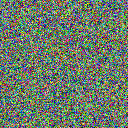
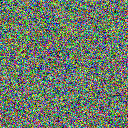
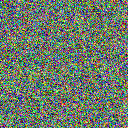
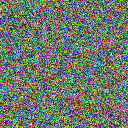
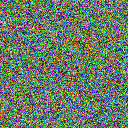
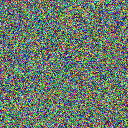
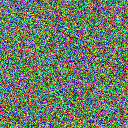
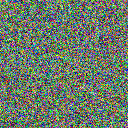
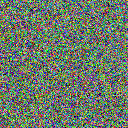
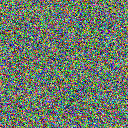
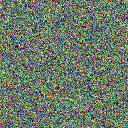
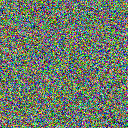

EDM Epoch 1 Loss: 0.7917:   0%|          | 3/10000 [00:02<1:32:06,  1.81it/s]

MLflow image logging failed: 'UNet128' object has no attribute 'sample'


EDM Epoch 1 Loss: 0.0442:   6%|▋         | 643/10000 [00:46<10:47, 14.46it/s]

In [ ]:

def train_some(model_edm,optimizer_edm,train_dataset,batch_size,train_loader, experiment_name, img_size=(3,64,64)):

    try:
        mlflow.end_run()
    except:
        pass
    mlflow.set_experiment(experiment_name)
    mlflow.start_run()
    model_name = model_edm.__class__.__name__
    total_params = sum(p.numel() for p in model_edm.parameters() if p.requires_grad)
    mlflow.log_param("model_name", model_name)
    mlflow.log_param("total_trainable_params", total_params)
    mlflow.log_param("img_size", img_size)
    mlflow.log_param("batch_size", batch_size)

    if resume:=False and diffusion_weights:
        load_checkpoint(model=model_edm, optimizer=optimizer_edm, path=diffusion_weights)
    ema = EMAHelper(model_edm)
    t0 = time.time()
    next_display_time = t0
    display_interval = 30*2
    next_display_time = time.time()
    checkpoint_interval = 60 * 60
    next_checkpoint_time = time.time() + checkpoint_interval
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    image_path = f"outputs/{timestamp}_CONT_{model_edm.__class__.__name__}_{experiment_name}_size=efficient.html"

    os.makedirs("outputs", exist_ok=True)
    with open("/tmp/training_running.txt","w"):
        pass
    for epoch in range(999999):
        pbar = tqdm(train_loader)
        if not os.path.exists("/tmp/training_running.txt"):
            break
        for batchnum,(x, _) in enumerate(pbar):
            if not os.path.exists("/tmp/training_running.txt"):
                break
            loss = train_a_batch(model_edm,optimizer_edm,x)
            ema.update(model_edm)
            pbar.set_description(f"EDM Epoch {epoch+1} Loss: {loss:.4f}")
            if time.time() > next_checkpoint_time:
                save_checkpoint(model_edm, optimizer_edm, epoch, loss, tag=experiment_name+"_efficient")
                next_checkpoint_time = time.time() + checkpoint_interval
            if time.time() > next_display_time:
                next_display_time += display_interval
                dt = time.strftime('%H:%M:%S', time.gmtime(time.time() - t0))
                h = sample_html(ema.get_model(),
                                min_height=32,
                                img_shape=(3,img_size,img_size), 
                                title=f"EDM of {model_edm.__class__.__name__} at {dt} {epoch}.{batchnum} loss {loss:.4f} ({timestamp})"
                                )
                with open(image_path,"a") as f:
                    f.write(h)
                ipd.clear_output(wait=True)
                ipd.display(ipd.HTML(h))

                # ------------------------------------------------------------
                # 🔥 MLFLOW: LOG METRICS
                # View with mlflow ui
                # ------------------------------------------------------------
                global_step = epoch * len(train_dataset) + batchnum * batch_size
                mlflow.log_metric("loss", float(loss), step=global_step)
                mlflow.log_metric("epoch", int(epoch), step=global_step)
                mlflow.log_metric("batch", int(batchnum), step=global_step)
                elapsed_seconds = time.time() - t0
                mlflow.log_metric("elapsed_sec", elapsed_seconds, step=global_step)
                try:
                    img = ema.get_model().sample(1)  # your sampler, returns tensor
                    img = (img[0].permute(1,2,0).detach().cpu().numpy() * 255).clip(0,255).astype(np.uint8)
                    pil = Image.fromarray(img)
                    with tempfile.NamedTemporaryFile(suffix=".png") as tmp:
                        pil.save(tmp.name)
                        mlflow.log_artifact(tmp.name, artifact_path="preview_images")
                except Exception as e:
                    print("MLflow image logging failed:", e)

    path = save_checkpoint(model_edm, optimizer_edm, epoch, loss, tag=experiment_name+"_efficient")
    path = save_checkpoint(ema.get_model(), optimizer_edm, epoch, loss, tag=experiment_name+"_efficient"+"_ema")
    del model_edm,optimizer_edm
    return path


# continue with different datset
# This is really cool.... You can train a Dragon SR model for hours; 
# # and in a few batches fine-tune as SR for handwriting.
# if resume := True:
#     rf = 'GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth
#     load_checkpoint(model=model, optimizer=optimizer, path=rf)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# dataset = 'mnist_grid'
# experiment_name = f'{dataset}_with_{vit_patch_size}px_patches'
# optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# lrds,paired_dataset = get_datasets(dataset)
# train_loader = DataLoader(paired_dataset, batch_size=4, shuffle=False)

#experiment_name = 'fantasy'
#experiment_name = 'pokemon'
experiment_name = 'mnist'
#experiment_name = 'dragon'

#experiment_name = 'cats_and_dogs'

img_size = 128
#lrds,_ = get_datasets(experiment_name)
model_edm = UNet128(use_attention=False).to(device)
#model_edm = create_gradual_transition_unet("balanced").to(device)   # great for pokemon
#model_edm = create_vit_enhanced_unet("balanced").to(device) # Hmm, this broke?

#model_edm =  create_semantic_coordinator(config='balanced', img_size=img_size).to(device)
total_params = sum(p.numel() for p in model_edm.parameters())
print(f"Total parameters: {total_params}")

optimizer_edm = optim.Adam(model_edm.parameters(), lr=2e-4)
if resume := False:
    rf = 'checkpoints/GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-25_08-14-08_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-26_08-50-06_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-24_08-35-13_fantasy_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-27_11-38-47_fantasy_efficient_ema.pth'
    # rf = 'checkpoints/GradualTransitionUNet_2025-11-22_23-38-53_cats_and_dogs_efficient.pth'

    load_checkpoint(model=model_edm, optimizer=optimizer_edm, path=rf)
    # intentionally roll back optimizer state in case the training data changed.
    optimizer = torch.optim.AdamW(model_edm.parameters(), lr = 1e-4)
train_dataset,_ = get_datasets(experiment_name,LR=img_size)
batch_size = 6*128*128 // img_size // img_size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

train_some(model_edm,optimizer_edm,train_dataset,batch_size,train_loader,experiment_name=experiment_name, img_size=img_size)

#train_some_sr(model, optimizer,paired_dataset,experiment_name=experiment_name, batch_size=2)

        


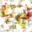
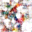
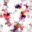
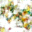
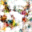
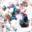
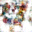
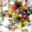
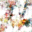
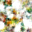
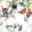
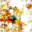

EDM Epoch 7 Loss: 0.1942:  77%|███████▋  | 321/418 [00:09<00:02, 34.68it/s]


KeyboardInterrupt: 

In [ ]:


# continue with different datset
# This is really cool.... You can train a Dragon SR model for hours; 
# # and in a few batches fine-tune as SR for handwriting.
# if resume := True:
#     rf = 'GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth
#     load_checkpoint(model=model, optimizer=optimizer, path=rf)
#     optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# dataset = 'mnist_grid'
# experiment_name = f'{dataset}_with_{vit_patch_size}px_patches'
# optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-4)
# lrds,paired_dataset = get_datasets(dataset)
# train_loader = DataLoader(paired_dataset, batch_size=4, shuffle=False)

#experiment_name = 'fantasy'
#experiment_name = 'pokemon'
experiment_name = 'mnist'
#experiment_name = 'dragon'

#experiment_name = 'cats_and_dogs'

img_size = 128
#lrds,_ = get_datasets(experiment_name)
#model_edm = UNet128(use_attention=False).to(device)
#model_edm = create_gradual_transition_unet("balanced").to(device)   # great for pokemon
model_edm = create_vit_enhanced_unet("balanced").to(device) # Hmm, this broke?

#model_edm =  create_semantic_coordinator(config='balanced', img_size=img_size).to(device)
total_params = sum(p.numel() for p in model_edm.parameters())
print(f"Total parameters: {total_params}")

optimizer_edm = optim.Adam(model_edm.parameters(), lr=2e-4)
if resume := False:
    rf = 'checkpoints/GradualTransitionUNet_2025-09-23_07-28-11_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-25_08-14-08_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-26_08-50-06_dragon_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-24_08-35-13_fantasy_efficient_ema.pth'
    rf = 'checkpoints/GradualTransitionUNet_2025-09-27_11-38-47_fantasy_efficient_ema.pth'
    # rf = 'checkpoints/GradualTransitionUNet_2025-11-22_23-38-53_cats_and_dogs_efficient.pth'

    load_checkpoint(model=model_edm, optimizer=optimizer_edm, path=rf)
    # intentionally roll back optimizer state in case the training data changed.
    optimizer = torch.optim.AdamW(model_edm.parameters(), lr = 1e-4)
train_dataset,_ = get_datasets(experiment_name,LR=img_size)
batch_size = 6*128*128 // img_size // img_size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

train_some(model_edm,optimizer_edm,train_dataset,batch_size,train_loader,experiment_name=experiment_name, img_size=img_size)

#train_some_sr(model, optimizer,paired_dataset,experiment_name=experiment_name, batch_size=2)


In [ ]:
model_edm

AdaptiveSemanticCoordinatorUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
  )
  (input_block): ConvBlock(
    (conv1): Conv2d(3, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=128, out_features=80, bias=True)
    (skip): Conv2d(3, 80, kernel_size=(1, 1), stride=(1, 1))
  )
  (input_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (encoder_blocks): ModuleList(
    (0): ConvBlock(
      (conv1): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_mlp): Linear(in_features=128, out_features=80, bias=True)
      (skip): Identity()
    )
    (1): ConvBlock(
      (conv1): Conv2d(80, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(320, 320, ke

In [ ]:
model_edm

AdaptiveSemanticCoordinatorUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): ReLU()
  )
  (input_block): ConvBlock(
    (conv1): Conv2d(3, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(80, 80, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (time_mlp): Linear(in_features=128, out_features=80, bias=True)
    (skip): Conv2d(3, 80, kernel_size=(1, 1), stride=(1, 1))
  )
  (input_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (encoder_blocks): ModuleList(
    (0): ConvBlock(
      (conv1): Conv2d(80, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_mlp): Linear(in_features=128, out_features=160, bias=True)
      (skip): Conv2d(80, 160, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): ConvBlock(
      (conv1): Conv2d(160, 320, kernel_size=(3, 3), stride=(1, 1), paddi

torch.Size([10, 3, 128, 128])


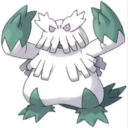

In [ ]:
samples = torch.stack([train_dataset[i][0] for i in range(10)])
print(samples.shape)
to_pil = transforms.ToPILImage()
with torch.no_grad():
    samples = (samples + 1) / 2  # scale from [-1,1] to [0,1]
    samples = samples.clamp(0, 1)
    pil_images = [to_pil(img) for img in samples]
pil_images[0]


in sample_haml  (3, 128, 128)
in genimgs  (3, 128, 128)
in edm_ancestral_sampling_for_diffusion shape is  (3, 128, 128)
in uified_edm_sampleing shape is  (3, 128, 128)



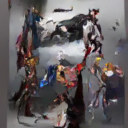
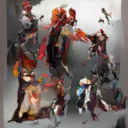
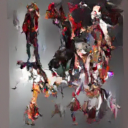
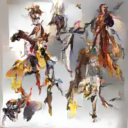
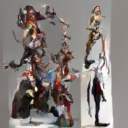
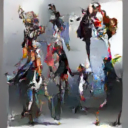
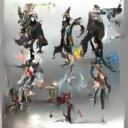
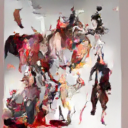
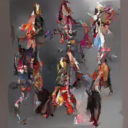
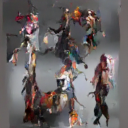
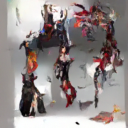
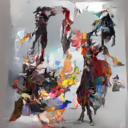
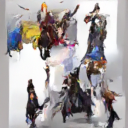
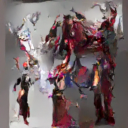
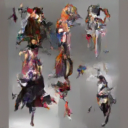
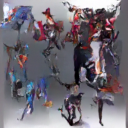
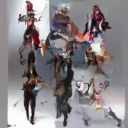
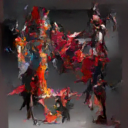
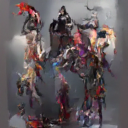
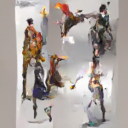
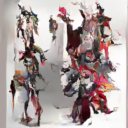
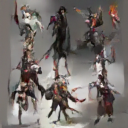
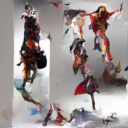
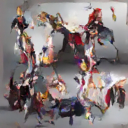

In [ ]:
h = sample_html(model_edm,title=f"Samples",min_height=256, batch_size=batch_size, img_shape=(3,128,128))
display(ipd.HTML(h))

## Inferrence

In [ ]:
#diffusion_weights = "checkpoints/UNet128_2025-09-08_17-57-30_cats_and_dogs.pth"
#diffusion_weights = "checkpoints/UNet128_2025-09-09_06-38-40_fantasy.pth"
#load_checkpoint(model_edm, optimizer_edm, diffusion_weights)

def generate_html_examples(cp="checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth",batch_size=12, img_shape=(3,128,128)):
    with torch.no_grad():
        model_edm = UNet128(use_attention=True).to(device)
        optimizer_edm = None
        load_checkpoint(model_edm, optimizer_edm, cp)
        h = sample_html(model_edm,title=f"Samples from {cp}",min_height=1024, batch_size=batch_size, img_shape=img_shape)
        ipd.display(ipd.HTML(h))
        model_edm.to('cpu')
        



🔄 Loaded checkpoint from checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth
    Epoch: 0, Loss: 0.10294210910797119
    Model class: UNet128
in sample_haml  (3, 64, 256)
in genimgs  (3, 64, 256)
in edm_ancestral_sampling_for_diffusion shape is  (3, 64, 256)
in uified_edm_sampleing shape is  (3, 64, 256)



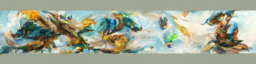
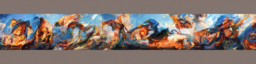
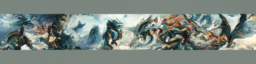
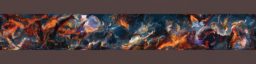
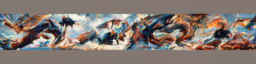
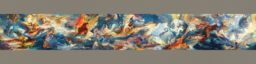

In [ ]:
cp = "checkpoints/UNet128_2025-09-14_02-20-07_fantasy.pth"
cp="checkpoints/UNet128_2025-09-12_19-47-15_dragon.pth"
generate_html_examples(cp=cp,batch_size=6,img_shape=(3,64,256))


🔄 Loaded checkpoint from checkpoints/UNet128_2025-09-14_02-09-02_dragon.pth
    Epoch: 1, Loss: 0.1339804232120514
    Model class: UNet128



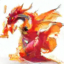
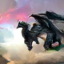
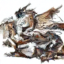
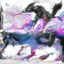
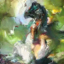
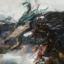

In [ ]:
generate_html_examples(cp="checkpoints/UNet128_2025-09-14_02-09-02_dragon.pth",batch_size=6)